In [1]:
#loading metacells of rna and atac data
import anndata
from anndata import AnnData
import pandas as pd
import scanpy as sc

#sc_rna = anndata.read_h5ad("/home/fgsasse_lrs_1/Downloads/BA/BA_data/SEAcells/SEACell_summarized_annot_RNA.h5ad")  
sc_atac = anndata.read_h5ad("/home/fgsasse_lrs_1/Downloads/BA/BA_data/SEAcells/SEACell_summarized_annot_ATAC.h5ad")

#window_sizes = ["100kb"]
#base_path = "/home/fgsasse_lrs_1/Downloads/BA/BA_data/TSS windows/20 windows"


#combined_gene_peaks = {}
#for window in window_sizes:
#    combined_gene_peaks[window] = pd.read_csv(f"{base_path}/combined_gene_peak_assignments_{window}.csv")

In [2]:
#function for normalizing the aggregated data by total counts per SEACell to get relative accessibility/expression values (compositional normalization)
def compositional_normalize_adata(adata):
    import pandas as pd
    import scipy.sparse as sp
    
    # extract to dense DataFrame
    if sp.issparse(adata.X):
        df = pd.DataFrame(adata.X.toarray(), index=adata.obs_names, columns=adata.var_names)
    else:
        df = pd.DataFrame(adata.X, index=adata.obs_names, columns=adata.var_names)
    
    # normalize
    row_sums = df.sum(axis=1)
    if (row_sums == 0).any():
        print(f"Warning: {(row_sums == 0).sum()} metacells with zero counts.")
    df_norm = df.div(row_sums, axis=0)
    
    # put back into AnnData, preserving obs/var metadata
    adata_norm = adata.copy()
    adata_norm.X = df_norm.values
    return adata_norm

#sc_rna_norm = compositional_normalize_adata(sc_rna)
sc_atac_norm = compositional_normalize_adata(sc_atac)

In [3]:
#check dimensions of the data
print(sc_atac_norm.X.shape)
print(sc_rna_norm.X.shape)

print(sc_atac_norm.obs_names)
print(sc_rna_norm.obs_names)

(1260, 640834)
(1260, 32057)
Index(['SEACell-91', 'SEACell-383', 'SEACell-141', 'SEACell-905',
       'SEACell-307', 'SEACell-1022', 'SEACell-1233', 'SEACell-786',
       'SEACell-172', 'SEACell-520',
       ...
       'SEACell-1112', 'SEACell-396', 'SEACell-611', 'SEACell-1138',
       'SEACell-1047', 'SEACell-712', 'SEACell-1081', 'SEACell-1004',
       'SEACell-654', 'SEACell-1154'],
      dtype='object', length=1260)
Index(['SEACell-91', 'SEACell-383', 'SEACell-141', 'SEACell-905',
       'SEACell-307', 'SEACell-1022', 'SEACell-1233', 'SEACell-786',
       'SEACell-172', 'SEACell-520',
       ...
       'SEACell-1112', 'SEACell-396', 'SEACell-611', 'SEACell-1138',
       'SEACell-1047', 'SEACell-712', 'SEACell-1081', 'SEACell-1004',
       'SEACell-654', 'SEACell-1154'],
      dtype='object', length=1260)


In [3]:
#Reindex the dataframes to ensure they are in the same order
sc_atac_norm = sc_atac_norm[sc_rna_norm.obs_names, :]
sc_rna_norm = sc_rna_norm[sc_atac_norm.obs_names, :]
print(sc_atac_norm.obs_names.equals(sc_rna_norm.obs_names))  # Should return True
sc_rna_norm.shape

True


(1260, 32057)

In [4]:
#Substract the genes that are present in the gene_peaks_10kb dataframe from the sc_rna_norm dataframe, to only keep the genes that have peaks assigned to them
combined_gene_peaks_100kb = combined_gene_peaks["100kb"]["gene_id"].tolist()
sc_rna_norm = sc_rna_norm[:, combined_gene_peaks_100kb] 
print(sc_rna_norm.shape)

NameError: name 'combined_gene_peaks' is not defined

In [6]:
print(sc_atac_norm.X)
print(sc_rna_norm.X)

[[1.50799434e-06 2.49389446e-06 2.49389446e-06 ... 0.00000000e+00
  2.30650248e-05 2.24851360e-05]
 [0.00000000e+00 2.90227198e-06 2.90227198e-06 ... 2.90227198e-06
  2.65433928e-05 2.61203838e-05]
 [1.07380480e-06 3.82898193e-06 1.86310341e-06 ... 0.00000000e+00
  2.38958283e-05 2.31796189e-05]
 ...
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 0.00000000e+00
  3.69086928e-05 3.75786249e-05]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 0.00000000e+00
  3.02830661e-05 2.98721850e-05]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 2.12457537e-05
  6.02530741e-05 5.90268286e-05]]
[[1.56366037e-05 0.00000000e+00 6.67375679e-05 ... 1.64575867e-04
  9.24402342e-05 8.63044632e-05]
 [1.16899211e-05 1.16899211e-05 7.63577082e-05 ... 1.00931131e-04
  7.63577082e-05 1.05990121e-04]
 [1.03954968e-05 1.86170539e-05 7.15386658e-05 ... 7.15386658e-05
  6.28814762e-05 1.00512697e-04]
 ...
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 0.00000000e+00
  2.99718954e-04 0.00000000e+00]

In [7]:
#taking the minimum non-zero value in the sc_rna_norm matrix to add it to all values before log transformation to avoid taking log of zero
import numpy as np
non_zero_mask = (sc_rna_norm.X > 0)
epsilon_rna = np.min(sc_rna_norm.X[non_zero_mask])

#taking the minimum non-zero value in the sc_atac_norm matrix to add it to all values before log transformation to avoid taking log of zero
non_zero_mask = (sc_atac_norm.X > 0)
epsilon_at= np.min(sc_atac_norm.X[non_zero_mask])

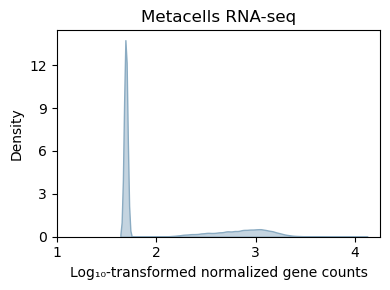

In [10]:
import numpy as np
import scipy.sparse as sp
import seaborn as sns
import matplotlib.pyplot as plt

# Minimum non-zero value
epsilon_rna = sc_rna_norm.X.data.min() if sp.issparse(sc_rna_norm.X) else sc_rna_norm.X[sc_rna_norm.X > 0].min()

# Convert only if sparse
X = sc_rna_norm.X.toarray() if sp.issparse(sc_rna_norm.X) else sc_rna_norm.X

# Log transform (including zeros)
log_cpm = np.log10((X + epsilon_rna) * 1e7).ravel()

plt.figure(figsize=(4, 3))
sns.kdeplot(
    x=log_cpm,
    fill=True,
    alpha=0.5,
    color="#8aabc2"
)

plt.xticks(np.arange(1, 5, 1))
plt.yticks(np.arange(0, 13, 3))
plt.xlabel("Log₁₀-transformed normalized gene counts")
plt.title("Metacells RNA-seq")
plt.tight_layout()
plt.savefig("seaborn_plot_rna.png", dpi=300)
plt.show()

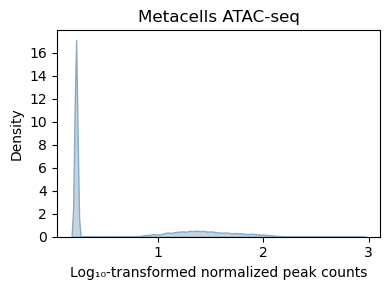

In [4]:
import numpy as np
import scipy.sparse as sp
import seaborn as sns
import matplotlib.pyplot as plt

# Minimum non-zero value
epsilon_at = sc_atac_norm.X.data.min() if sp.issparse(sc_atac_norm.X) else sc_atac_norm.X[sc_atac_norm.X > 0].min()

# Randomly sample peaks for plotting
n_plot_peaks = min(200000, sc_atac_norm.shape[1])
peak_idx = np.random.choice(sc_atac_norm.shape[1], n_plot_peaks, replace=False)

X = sc_atac_norm[:, peak_idx].X

# Convert only sampled data to dense
if sp.issparse(X):
    X = X.toarray()

# Log transform (including zeros)
log_cpm = np.log10((X + epsilon_at) * 1e7).ravel()

plt.figure(figsize=(4, 3))
sns.kdeplot(
    x=log_cpm,
    fill=True,
    alpha=0.5,
    color="#8aabc2"
)

plt.xlabel("Log₁₀-transformed normalized peak counts")
plt.title("Metacells ATAC-seq")
plt.xticks(np.arange(1, 4, 1))
plt.yticks(np.arange(0, 17, 2))
plt.tight_layout()
plt.savefig("seaborn_plot_atac.png", dpi=300)
plt.show()

In [ ]:
# convert to long format for seaborn
P_rna_scaled_plot = pd.DataFrame(P_rna_scaled, columns=sc_rna_norm.obs_names).melt(
	var_name="celltype",
	value_name="log_cpm"
)
#Plotting the distribution of values of the genes across all cell types in a density plot for RNA data
plt.figure(figsize=(4, 2))
sns.kdeplot(data=P_rna_scaled_plot, x="log_cpm", common_norm=False, fill=True, alpha=0.5, color="#8aabc2")
plt.xlabel("Log₁₀-transformed normalized gene counts") 
plt.title("Density of log10((RNA + min(RNA)) * 10000000) across cell type")
plt.tight_layout()
plt.savefig("seaborn_plot.png", dpi=300)
plt.show()

In [4]:
#taking the minimum non-zero value in the sc_atac_norm matrix to add it to all values before log transformation to avoid taking log of zero 
import numpy as np
non_zero_mask = (sc_atac_norm.X > 0)
epsilon_at= np.min(sc_atac_norm.X[non_zero_mask])

In [ ]:
#taking the minimum non-zero value in the sc_atac_norm matrix to add it to all values before log transformation to avoid taking log of zero 
import numpy as np
non_zero_mask = (sc_atac_norm.X > 0)
epsilon_at= np.min(sc_atac_norm.X[non_zero_mask])

#Plotting the distribution of the value of the peaks across all cell types in a boxplot for ATAC data
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

#first take only half of the peaks (features) to avoid overplotting
sc_atac_norm = sc_atac_norm[np.random.choice(sc_atac_norm.shape[1], size= sc_atac_norm.shape[1]//2, replace=False), :]

P_atac_scaled = np.log10((sc_atac_norm.X+ epsilon_at)*10000000) 

# ATAC counts x samples
P_atac_scaled = P_atac_scaled.T.astype(float)

# convert to long format for seaborn
P_atac_scaled_plot = pd.DataFrame(P_atac_scaled, columns=sc_atac_norm.obs_names).melt(
	var_name="SEACell",
	value_name="log_cpm"
)
#Plotting the distribution of values of the peaks across all cell types in a density plot for ATAC data
plt.figure(figsize=(4, 2))
sns.kdeplot(data=P_atac_scaled_plot, x="log_cpm", common_norm=False, fill=True, alpha=0.5, color="#8aabc2")
plt.xlabel("Log₁₀-transformed normalized peak counts")
plt.title("Density of log₁₀((ATAC + min(ATAC)) × 10⁷) across SEACells")
plt.tight_layout()
plt.savefig("seaborn_plot_atac.png", dpi=300)
plt.show()



/tmp/ipykernel_3827414/908349865.py:31: RuntimeWarning: divide by zero encountered in log10
  log_cpm = np.log10((X + epsilon_at) * 1e7).ravel()


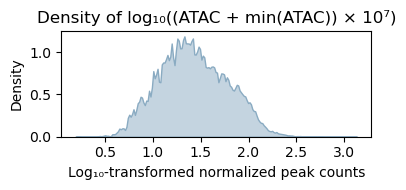

In [5]:
import numpy as np
import scipy.sparse as sp
import seaborn as sns
import matplotlib.pyplot as plt


# Minimum non-zero value
epsilon_at = sc_atac_norm.X.min()

# Compute mean peak accessibility without log transformation
peak_means = np.asarray(sc_atac_norm.X.mean(axis=0)).ravel()

# Peaks below and above threshold
small_idx = np.where(peak_means < 0.5)[0]
large_idx = np.where(peak_means > 0.5)[0]

# Sample peaks
selected_peaks = np.concatenate([
    np.random.choice(small_idx, len(small_idx) // 5, replace=False),
    np.random.choice(large_idx, len(large_idx) // 4, replace=False)
])

# Subset only the selected peaks
X = sc_atac_norm[:, selected_peaks].X

# Convert only the subset to dense (if sparse)
if sp.issparse(X):
    X = X.toarray()

# Log transform only the subset
log_cpm = np.log10((X + epsilon_at) * 1e7).ravel()
plt.figure(figsize=(4, 2))
sns.kdeplot(x=log_cpm, fill=True, alpha=0.5, color="#8aabc2")
plt.xlabel("Log₁₀-transformed normalized peak counts")

plt.title("Density of log₁₀((ATAC + min(ATAC)) × 10⁷)")
plt.tight_layout()
plt.savefig("seaborn_plot_atac.png", dpi=300)
plt.show()

In [ ]:
import numpy as np
import scipy.sparse as sp
import seaborn as sns
import matplotlib.pyplot as plt

# Sparse matrix (cells × peaks)
X = sc_atac_norm.X

# Smallest non-zero value
epsilon = X.min()

# ----------- sample peaks BEFORE anything else -----------
n_plot_peaks = min(600000, X.shape[1])      # adjust (5000–20000 works well)

peak_idx = np.random.choice(
    X.shape[1],
    size=n_plot_peaks,
    replace=False
)

X = X[:, peak_idx]

# ----------- convert only sampled peaks to dense ----------
if sp.issparse(X):
    X = X.toarray()

# ----------- log transform -------------------------------
values = np.log10((X + epsilon) * 1e7).ravel()

# ----------- plot ----------------------------------------
plt.figure(figsize=(4,3))

sns.kdeplot(
    x=values,
    fill=True,
    alpha=0.5,
    color="#8aabc2",
    bw_adjust=0.8
)

plt.xlabel("Log₁₀-transformed normalized peak counts")
plt.title("Metacells ATAC-seq")
plt.tight_layout()
plt.xticks(np.arange(0, 4, 1))
plt.yticks(np.arange(0, 1.3, 0.5))
plt.savefig("seaborn_plot_atac.png", dpi=300)
plt.show()

/tmp/ipykernel_3837049/1813094205.py:28: RuntimeWarning: divide by zero encountered in log10
  values = np.log10((X + epsilon) * 1e7).ravel()


In [ ]:
#log transformation (for norm. distribution) & scaling 10000000+1
#log scaling both datasets by multiplying by 10 million and adding 1 to avoid log(0) issues, then taking log10
sc_rna_norm.X = np.log10((sc_rna_norm.X+ epsilon_rna)*10000000) 
sc_atac_norm.X = np.log10((sc_atac_norm.X+ epsilon_at)*10000000)
print(sc_atac_norm.X)
print(sc_rna_norm.X)

In [ ]:
from pathlib import Path
import sys

repo_root = Path("/home/fgsasse_lrs_1/Downloads/BA")
src_path = repo_root / "src"
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

from your_package.correlation import (
    DEFAULT_WINDOW_LABELS,
    add_correlation_categories,
    aggregate_correlation_categories,
    build_correlation_dataframe,
    compute_all_window_peak_correlations,
)

window_assignments = {
    "100kb": combined_gene_peaks["100kb"],
}

all_window_results = compute_all_window_peak_correlations(
    atac_data=sc_atac_norm,
    rna_data=sc_rna_norm,
    window_assignments=window_assignments,
)

cor_res_df = build_correlation_dataframe(
    all_window_results,
    window_labels=DEFAULT_WINDOW_LABELS,
)

#save the correlation results as a csv file
cor_res_df.to_csv("/home/fgsasse_lrs_1/Downloads/BA/BA_data/Correlations/Results/gene_peak_correlation_sc_100kb_results.csv", index=False)

cor_res_df = add_correlation_categories(cor_res_df)
agg_cor_df = aggregate_correlation_categories(cor_res_df)


print(cor_res_df.shape)
print(cor_res_df.head())
print(agg_cor_df.head())

# Dedublication
of gene-peak pairs, meaning we keep only the first occurrence of each pair across all windows
- ordering by window size, we keep the pair with the smallest window size

In [ ]:
# classify every peak–gene pair into one of three categories 
def classify_pair(row):
    if row["padj"] <= 0.05 and row["correlation"] < 0:
        return "sig. negative"
    elif row["padj"] <= 0.05 and row["correlation"] > 0:
        return "sig. positive"
    else:
        return "non-significant"

cor_res_df["category"] = cor_res_df.apply(classify_pair, axis=1)

# Make window categorical and ordered
cor_res_df["window"] = pd.Categorical(
    cor_res_df["window"],
    categories=["10kb", "20kb", "50kb", "100kb"],
    ordered=True
)

# Order by window
cor_res_df = cor_res_df.sort_values("window", ascending=True)
cor_res_df

cor_res_df["category"] = cor_res_df.apply(classify_pair, axis=1)

# "Dedublication" of gene-peak pairs by keeping only the first occurrence of each pair across all windows (since they are ordered by window size, this will keep the pair with the smallest window size)"
pair_summary = (
    cor_res_df
    .groupby(["gene", "peak"], as_index=False)
    .first()
)

# Sort by window 
pair_summary = pair_summary.sort_values("window", ascending=True)
pair_summary

# Sanity check - how many times each gene-peak pair appears in the summary
pair_counts = pair_summary.groupby(["gene", "peak"]).size().reset_index(name="count")
pair_counts['count'].value_counts()

# Counts how many unique gene-peak pairs fall into each category for each window size
summary_counts = pair_summary.groupby(['window', 'gene', 'category']).size().reset_index(name="count")
summary_counts


In [ ]:
#Boxplot of the counts of peaks per gene (first occurrence of gene-peak pair across all windows) for each category and window size
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

category_order  = ["sig. negative", "non-significant", "sig. positive"]
category_colors = {
    "sig. negative":   "#D43737",
    "sig. positive":   "#1A8EB9",
    "non-significant": "#A9A9A9",
}

fig, ax = plt.subplots(figsize=(9, 6))
fig.patch.set_facecolor("white")
ax.set_facecolor("#F8F8F8")

sns.boxplot(
    data=summary_counts,
    x="window", y="count", hue="category",
    hue_order=category_order,
    palette=category_colors,
    width=0.6,
    linewidth=1.2,
    fill=True,
    flierprops=dict(marker="o", markersize=4, linewidth=0),
    boxprops=dict(alpha=1),
    gap=0.1,
    ax=ax,
)

# Replace x-axis tick labels
window_labels = {
    "10kb":  "±TSS–10 kb",
    "20kb":  "±10–20 kb",
    "50kb":  "±20–50 kb",
    "100kb": "±50–100 kb",
}
ax.set_xticklabels([window_labels[t.get_text()] for t in ax.get_xticklabels()])

# Recolor fliers manually to match their box color
for line, color in zip(
    [c for c in ax.get_lines() if c.get_linestyle() == "none"],
    [category_colors[cat]
     for _ in summary_counts["window"].cat.categories
     for cat in category_order]
):
    line.set_markerfacecolor(color)
    line.set_markeredgecolor(color)
    line.set_alpha(0.7)

ax.set_title("Peak counts per gene across genomic windows (SEACells)",
             fontsize=14, fontweight="500", pad=14, loc="center")
ax.set_xlabel("Genomic window", fontsize=11, labelpad=8)
ax.set_ylabel("# significant peaks per gene", fontsize=11, labelpad=8)

ax.yaxis.grid(True, color="#cccccc", linewidth=0.8, linestyle="-", zorder=0)
ax.xaxis.grid(False)
ax.set_axisbelow(True)

for spine in ax.spines.values():
    spine.set_color("#a5a4a4")

handles = [mpatches.Patch(color=category_colors[c], alpha=1, label=c.capitalize())
           for c in category_order]
ax.legend(
    handles=handles,
    title="Correlation Category\n(padj ≤ 0.05)",
    frameon=True,
    fontsize=10,
    loc="upper left",
    title_fontsize=10,
)

plt.tight_layout()
plt.show()

In [ ]:
# Boxplot of the counts of peaks per gene (first occurrence of gene-peak pair across all windows) for significant categories only (non-significant category excluded) for each window size
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

category_order  = ["sig. negative", "sig. positive"]
category_colors = {
    "sig. negative":   "#D43737",
    "sig. positive":   "#1A8EB9",
}

only_sig = summary_counts[summary_counts["category"] != "non-significant"]

fig, ax = plt.subplots(figsize=(9, 6))
fig.patch.set_facecolor("white")
ax.set_facecolor("#F8F8F8")

sns.boxplot(
    data=only_sig,
    x="window", y="count", hue="category",
    hue_order=category_order,
    palette=category_colors,
    width=0.6,
    linewidth=1.2,
    fill=True,
    flierprops=dict(marker="o", markersize=4, linewidth=0),
    boxprops=dict(alpha=1),
    gap=0.1,
    ax=ax,
)

# Replace x-axis tick labels
window_labels = {
    "10kb":  "±TSS–10 kb",
    "20kb":  "±10–20 kb",
    "50kb":  "±20–50 kb",
    "100kb": "±50–100 kb",
}
ax.set_xticklabels([window_labels[t.get_text()] for t in ax.get_xticklabels()])

# Recolor fliers manually to match their box color
for line, color in zip(
    [c for c in ax.get_lines() if c.get_linestyle() == "none"],
    [category_colors[cat]
     for _ in only_sig["window"].cat.categories
     for cat in category_order]
):
    line.set_markerfacecolor(color)
    line.set_markeredgecolor(color)
    line.set_alpha(0.7)

ax.set_title("Peak counts per gene across genomic windows (SEACells)",
             fontsize=14, fontweight="500", pad=14, loc="center")
ax.set_xlabel("Genomic window", fontsize=11, labelpad=8)
ax.set_ylabel("# significant peaks per gene", fontsize=11, labelpad=8)

ax.yaxis.grid(True, color="#cccccc", linewidth=0.8, linestyle="-", zorder=0)
ax.xaxis.grid(False)
ax.set_axisbelow(True)

for spine in ax.spines.values():
    spine.set_color("#a5a4a4")

handles = [mpatches.Patch(color=category_colors[c], alpha=1, label=c.capitalize())
           for c in category_order]
ax.legend(
    handles=handles,
    title="Correlation Category\n(padj ≤ 0.05)",
    frameon=True,
    fontsize=10,
    loc="upper left",
    title_fontsize=10,
)

plt.tight_layout()
plt.show()